给定 n 个非负整数表示每个宽度为 1 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水

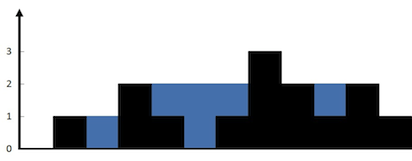

>输入：height = [0,1,0,2,1,0,1,3,2,1,2,1]  
>输出：6

### 单调栈

In [ ]:
class Solution:
    def trap(self, height: List[int]) -> int:
        stack = []
        size = len(height)
        ans = 0

        for i in range(size):
            while stack and height[i] > height[stack[-1]]:
                cur = stack.pop(-1)
                if stack:
                    left = stack[-1]
                    right = i
                    high = min(height[i], height[stack[-1]]) - height[cur]
                    ans += (right - left - 1) * high
                else:
                    break
            stack.append(i)
        
        return ans

从左到右遍历数组，遍历到下标 $i$ 时，如果栈内至少有两个元素，记栈顶元素为 $top$，$top$ 的下面一个元素是 $left$，则一定有 $height[left]≥height[top]$。如果 $height[i]>height[top]$，则得到一个可以接雨水的区域，该区域的宽度是 $i−left−1$，高度是 $min(height[left],height[i])−height[top]$，根据宽度和高度即可计算得到该区域能接的雨水量。

为了得到 $left$，需要将 $top$ 出栈。在对 $top$ 计算能接的雨水量之后，$left$ 变成新的 $top$，重复上述操作，直到栈变为空，或者栈顶下标对应的 $height$ 中的元素大于或等于 $height[i]$

### 双指针

In [ ]:
class Solution:
    def trap(self, height: List[int]) -> int:
        ans = 0
        left, right = 0, len(height) - 1
        leftMax = rightMax = 0

        while left < right:
            leftMax = max(leftMax, height[left])
            rightMax = max(rightMax, height[right])
            if height[left] < height[right]:
                ans += leftMax - height[left]
                left += 1
            else:
                ans += rightMax - height[right]
                right -= 1
        
        return ans

使用 $height[left]$ 和 $height[right]$ 的值更新 $leftMax$ 和 $rightMax$ 的值；

如果 $height[left]<height[right]$，则必有 $leftMax<rightMax$，下标 $left$ 处能接的雨水量等于 $leftMax−height[left]$，将下标 $left$ 处能接的雨水量加到能接的雨水总量，然后将 $left$ 加 1（即向右移动一位）；

如果 $height[left]≥height[right]$，则必有 $leftMax≥rightMax$，下标 $right$ 处能接的雨水量等于 $rightMax−height[right]$，将下标 $right$ 处能接的雨水量加到能接的雨水总量，然后将 $right$ 减 1（即向左移动一位）。